In [ ]:
# ============================================================
# PARTIE II — CNN et vision par ordinateur
# Dataset : MNIST (chiffres manuscrits 0-9)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

torch.manual_seed(42)
np.random.seed(42)

print("PyTorch :", torch.__version__)
print("GPU     :", torch.cuda.is_available())

PyTorch : 2.10.0+cpu
GPU     : False


100%|██████████| 9.91M/9.91M [00:00<00:00, 38.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 947kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.00MB/s]


Train : 60,000 images
Test  : 10,000 images
Shape d'une image : torch.Size([1, 28, 28])


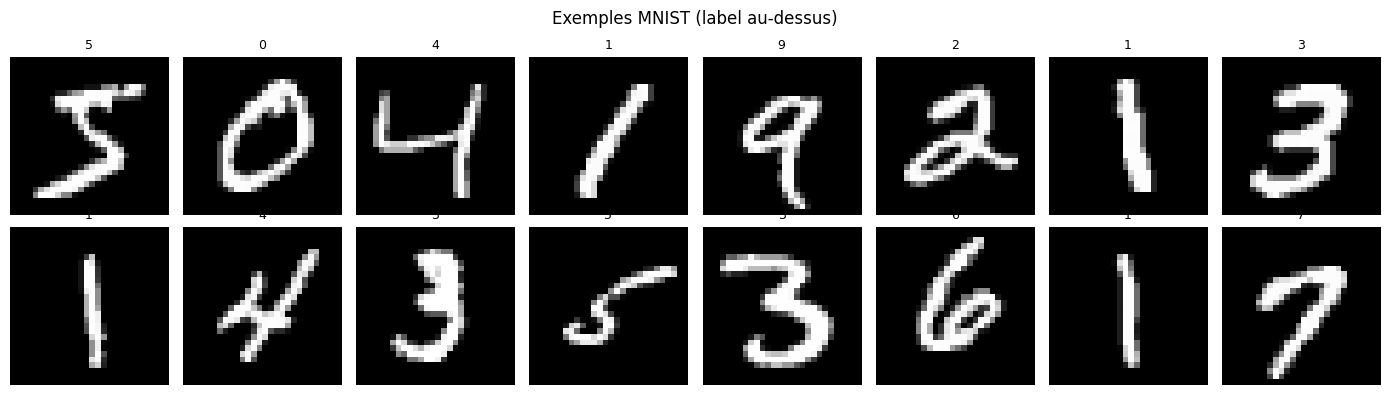

In [ ]:
# ============================================================
# CHARGEMENT MNIST
# ============================================================
# MNIST : 70 000 images en niveaux de gris, 28×28 pixels
# 10 classes (chiffres 0 à 9)
# 60 000 train / 10 000 test

transform = transforms.Compose([
    transforms.ToTensor(),            # [0,255] → [0.0, 1.0]
    transforms.Normalize((0.1307,), (0.3081,))  # moyenne et std de MNIST
])

train_data = datasets.MNIST(root='./data', train=True,
                             download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False,
                             download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

print(f"Train : {len(train_data):,} images")
print(f"Test  : {len(test_data):,} images")
print(f"Shape d'une image : {train_data[0][0].shape}")  # [1, 28, 28]

# --- Visualisation de quelques exemples ---
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=9)
    ax.axis('off')
plt.suptitle("Exemples MNIST (label au-dessus)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CORRÉLATION CROISÉE 2D — IMPLÉMENTATION MANUELLE
# ============================================================
# La convolution CNN est techniquement une corrélation croisée :
# on glisse le kernel sur l'input et on calcule la somme
# élément par élément à chaque position.
#
# Formule : Output[i,j] = Σ_ki Σ_kj Input[i+ki, j+kj] * Kernel[ki, kj]
# ============================================================

def corr2d_manual(X, K):
    """
    Corrélation croisée 2D sans padding, stride=1.
    X : numpy array (h, w) — image d'entrée
    K : numpy array (kh, kw) — noyau de convolution
    Retourne : numpy array de taille (h-kh+1, w-kw+1)
    """
    h, w   = X.shape
    kh, kw = K.shape
    out_h  = h - kh + 1
    out_w  = w - kw + 1

    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            # Extraction de la fenêtre et produit élément par élément
            fenetre = X[i:i+kh, j:j+kw]
            Y[i, j] = np.sum(fenetre * K)
    return Y


# --- Test sur un exemple simple ---
X_test = np.array([[1,2,3,0,1],
                   [0,1,2,3,1],
                   [1,0,1,2,0],
                   [2,1,0,1,2],
                   [0,2,1,0,1]], dtype=float)

# Kernel de détection de contours (Laplacien)
K_edge = np.array([[ 0,-1, 0],
                   [-1, 4,-1],
                   [ 0,-1, 0]], dtype=float)

# Kernel de flou (moyenne)
K_blur = np.ones((3,3)) / 9.0

Y_edge = corr2d_manual(X_test, K_edge)
Y_blur = corr2d_manual(X_test, K_blur)

print("=== Corrélation croisée 2D ===")
print(f"Input shape  : {X_test.shape}")
print(f"Kernel shape : {K_edge.shape}")
print(f"Output shape : {Y_edge.shape}  ← (5-3+1) × (5-3+1)")
print(f"\nOutput (edge kernel):\n{Y_edge}")
print(f"\nOutput (blur kernel):\n{Y_blur.round(3)}")


# --- Vérification avec PyTorch nn.Conv2d ---
# On crée une conv2d avec les mêmes poids pour vérifier
X_torch = torch.tensor(X_test, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # [1,1,5,5]

conv = nn.Conv2d(in_channels=1, out_channels=1,
                 kernel_size=3, padding=0, bias=False)

# Forcer les poids à être notre kernel
with torch.no_grad():
    conv.weight[:] = torch.tensor(K_edge, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

Y_torch = conv(X_torch).detach().numpy().squeeze()

print(f"\n=== Vérification PyTorch ===")
print(f"Résultat manuel  :\n{Y_edge}")
print(f"Résultat PyTorch :\n{Y_torch}")
print(f"\nDifférence max : {np.abs(Y_edge - Y_torch).max():.6f}  ← doit être ~0")

=== Corrélation croisée 2D ===
Input shape  : (5, 5)
Kernel shape : (3, 3)
Output shape : (3, 3)  ← (5-3+1) × (5-3+1)

Output (edge kernel):
[[ 0.  0.  7.]
 [-4.  0.  3.]
 [ 0. -4.  0.]]

Output (blur kernel):
[[1.222 1.556 1.444]
 [0.889 1.222 1.333]
 [0.889 0.889 0.889]]

=== Vérification PyTorch ===
Résultat manuel  :
[[ 0.  0.  7.]
 [-4.  0.  3.]
 [ 0. -4.  0.]]
Résultat PyTorch :
[[ 0.  0.  7.]
 [-4.  0.  3.]
 [ 0. -4.  0.]]

Différence max : 0.000000  ← doit être ~0


In [ ]:
# ============================================================
# MAX-POOLING ET AVERAGE-POOLING MANUELS
# ============================================================
# Le pooling réduit la taille spatiale tout en conservant
# l'information essentielle.
# Max-pooling : prend la valeur maximale dans chaque fenêtre
#   → robuste aux translations, préserve les features saillantes
# Avg-pooling : prend la moyenne
#   → lissage, utile pour les représentations globales
# ============================================================

def max_pool2d_manual(X, pool_size=2, stride=2):
    """Max-pooling 2D manuel."""
    h, w = X.shape
    ph, pw = pool_size, pool_size
    out_h = (h - ph) // stride + 1
    out_w = (w - pw) // stride + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            fenetre = X[i*stride:i*stride+ph, j*stride:j*stride+pw]
            Y[i, j] = np.max(fenetre)
    return Y

def avg_pool2d_manual(X, pool_size=2, stride=2):
    """Average-pooling 2D manuel."""
    h, w = X.shape
    ph, pw = pool_size, pool_size
    out_h = (h - ph) // stride + 1
    out_w = (w - pw) // stride + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            fenetre = X[i*stride:i*stride+ph, j*stride:j*stride+pw]
            Y[i, j] = np.mean(fenetre)
    return Y


# --- Test ---
X_pool = np.array([[3,1,2,4],
                   [5,6,1,2],
                   [1,2,7,3],
                   [4,3,2,1]], dtype=float)

Y_max = max_pool2d_manual(X_pool, pool_size=2, stride=2)
Y_avg = avg_pool2d_manual(X_pool, pool_size=2, stride=2)

print("=== Pooling manuel ===")
print(f"Input (4×4) :\n{X_pool}")
print(f"\nMax-pool (2×2, stride 2) — taille : {Y_max.shape}\n{Y_max}")
print(f"\nAvg-pool (2×2, stride 2) — taille : {Y_avg.shape}\n{Y_avg}")

# --- Vérification PyTorch ---
X_pt = torch.tensor(X_pool, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

mp = nn.MaxPool2d(kernel_size=2, stride=2)
ap = nn.AvgPool2d(kernel_size=2, stride=2)

Y_max_pt = mp(X_pt).numpy().squeeze()
Y_avg_pt = ap(X_pt).numpy().squeeze()

print(f"\n=== Vérification PyTorch ===")
print(f"MaxPool PyTorch :\n{Y_max_pt}")
print(f"AvgPool PyTorch :\n{Y_avg_pt}")
print(f"\nDifférence max (max-pool) : {np.abs(Y_max - Y_max_pt).max():.6f}")
print(f"Différence max (avg-pool) : {np.abs(Y_avg - Y_avg_pt).max():.6f}")

=== Pooling manuel ===
Input (4×4) :
[[3. 1. 2. 4.]
 [5. 6. 1. 2.]
 [1. 2. 7. 3.]
 [4. 3. 2. 1.]]

Max-pool (2×2, stride 2) — taille : (2, 2)
[[6. 4.]
 [4. 7.]]

Avg-pool (2×2, stride 2) — taille : (2, 2)
[[3.75 2.25]
 [2.5  3.25]]

=== Vérification PyTorch ===
MaxPool PyTorch :
[[6. 4.]
 [4. 7.]]
AvgPool PyTorch :
[[3.75 2.25]
 [2.5  3.25]]

Différence max (max-pool) : 0.000000
Différence max (avg-pool) : 0.000000


In [ ]:
# ============================================================
# CNN INSPIRÉ DE LENET-5
# ============================================================
# LeNet (LeCun, 1998) est l'architecture fondatrice des CNN.
# Structure originale : Conv → Pool → Conv → Pool → FC → FC
#
# Pourquoi CNN plutôt que MLP sur des images ?
#   1. Localité : un pixel est lié à ses voisins, pas à tout l'image
#   2. Partage des poids : le même filtre détecte un motif partout
#   3. Hiérarchie : couches basses = bords, hautes = formes complexes
#   4. Paramètres : CNN 28×28 = ~60K params vs MLP = des millions
# ============================================================

class LeNet(nn.Module):
    """
    CNN inspiré de LeNet-5 pour MNIST (images 1×28×28).

    Architecture :
      Conv1(1→6, 5×5, p=2) → ReLU → AvgPool(2×2)   → [6×14×14]
      Conv2(6→16, 5×5)     → ReLU → AvgPool(2×2)   → [16×5×5]
      Flatten                                        → [400]
      FC1(400→120)         → ReLU
      FC2(120→84)          → ReLU
      FC3(84→10)
    """
    def __init__(self):
        super().__init__()
        # Bloc convolutionnel 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6,
                               kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Bloc convolutionnel 2
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16,
                               kernel_size=5, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Classifieur fully connected
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # Bloc 1 : [1,28,28] → [6,14,14]
        x = self.pool1(F.relu(self.conv1(x)))
        # Bloc 2 : [6,14,14] → [16,5,5]
        x = self.pool2(F.relu(self.conv2(x)))
        # Aplatissement : [16,5,5] → [400]
        x = x.flatten(start_dim=1)
        # Classifieur
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


model_lenet = LeNet()
print("=== Architecture LeNet ===")
print(model_lenet)

# Calcul des dimensions à chaque étape
print("\n=== Propagation des dimensions ===")
x = torch.randn(1, 1, 28, 28)
print(f"Input           : {x.shape}")
x = model_lenet.pool1(F.relu(model_lenet.conv1(x)))
print(f"Après Conv1+Pool: {x.shape}  ← (28+2×2-5)/1+1=28 → pool → 14")
x = model_lenet.pool2(F.relu(model_lenet.conv2(x)))
print(f"Après Conv2+Pool: {x.shape}  ← (14-5)/1+1=10 → pool → 5")
x = x.flatten(start_dim=1)
print(f"Après flatten   : {x.shape}  ← 16×5×5 = 400")

total = sum(p.numel() for p in model_lenet.parameters())
print(f"\nTotal paramètres : {total:,}")

=== Architecture LeNet ===
LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

=== Propagation des dimensions ===
Input           : torch.Size([1, 1, 28, 28])
Après Conv1+Pool: torch.Size([1, 6, 14, 14])  ← (28+2×2-5)/1+1=28 → pool → 14
Après Conv2+Pool: torch.Size([1, 16, 5, 5])  ← (14-5)/1+1=10 → pool → 5
Après flatten   : torch.Size([1, 400])  ← 16×5×5 = 400

Total paramètres : 61,706


In [ ]:
# ============================================================
# BOUCLE D'ENTRAÎNEMENT
# ============================================================

def train_cnn(model, train_loader, test_loader,
              epochs=10, lr=1e-3, model_name="lenet"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_acc": []}
    best_acc = 0.0

    for epoch in range(epochs):
        # --- Entraînement ---
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # --- Évaluation ---
        model.eval()
        correct = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                preds = model(X_batch.to(device)).argmax(1).cpu()
                correct += (preds == y_batch).sum().item()

        acc = correct / len(test_loader.dataset)
        avg_loss = total_loss / len(train_loader)
        history["train_loss"].append(avg_loss)
        history["test_acc"].append(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"best_{model_name}.pt")

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

    print(f"\nMeilleure accuracy : {best_acc:.4f}")
    return history

print("=== Entraînement LeNet sur MNIST ===")
hist_lenet = train_cnn(model_lenet, train_loader, test_loader,
                       epochs=10, model_name="lenet")

=== Entraînement LeNet sur MNIST ===
Epoch  1/10 | Loss: 0.2913 | Acc: 0.9720
Epoch  2/10 | Loss: 0.0877 | Acc: 0.9822
Epoch  3/10 | Loss: 0.0605 | Acc: 0.9813
Epoch  4/10 | Loss: 0.0492 | Acc: 0.9872
Epoch  5/10 | Loss: 0.0388 | Acc: 0.9844
Epoch  6/10 | Loss: 0.0334 | Acc: 0.9875
Epoch  7/10 | Loss: 0.0280 | Acc: 0.9892
Epoch  8/10 | Loss: 0.0252 | Acc: 0.9859
Epoch  9/10 | Loss: 0.0227 | Acc: 0.9885
Epoch 10/10 | Loss: 0.0170 | Acc: 0.9874

Meilleure accuracy : 0.9892


In [ ]:
# ============================================================
# ÉTUDE EXPÉRIMENTALE : influence des choix architecturaux
# On fait varier UN paramètre à la fois (toutes choses égales)
# ============================================================

def build_variant(pool_type='avg', n_filters=16,
                  use_conv1x1=False, padding=2, stride=1):
    """Construit une variante de LeNet avec des paramètres variables."""
    pool_layer = nn.AvgPool2d if pool_type == 'avg' else nn.MaxPool2d

    class Variant(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv2d(1, 6, 5, padding=padding, stride=stride)
            self.pool1 = pool_layer(2, 2)
            self.conv2 = nn.Conv2d(6, n_filters, 5)
            self.pool2 = pool_layer(2, 2)
            # Convolution 1×1 optionnelle : change le nombre de canaux
            # sans modifier la résolution spatiale
            self.conv1x1 = nn.Conv2d(n_filters, n_filters//2, 1) if use_conv1x1 else None
            out_ch = n_filters//2 if use_conv1x1 else n_filters
            # Calcul dynamique de la taille après les convolutions
            with torch.no_grad():
                dummy = torch.zeros(1, 1, 28, 28)
                dummy = self.pool1(F.relu(self.conv1(dummy)))
                dummy = self.pool2(F.relu(self.conv2(dummy)))
                if self.conv1x1:
                    dummy = self.conv1x1(dummy)
                self.flat_size = dummy.flatten(1).shape[1]
            self.fc1 = nn.Linear(self.flat_size, 84)
            self.fc2 = nn.Linear(84, 10)

        def forward(self, x):
            x = self.pool1(F.relu(self.conv1(x)))
            x = self.pool2(F.relu(self.conv2(x)))
            if self.conv1x1:
                x = self.conv1x1(x)
            x = x.flatten(1)
            return self.fc2(F.relu(self.fc1(x)))

    return Variant()


variants = {
    "LeNet base (avg, 16f)":       build_variant(pool_type='avg',  n_filters=16),
    "MaxPool (max, 16f)":          build_variant(pool_type='max',  n_filters=16),
    "Plus de filtres (avg, 32f)":  build_variant(pool_type='avg',  n_filters=32),
    "Conv 1×1 (avg, 16f+1x1)":    build_variant(pool_type='avg',  n_filters=16, use_conv1x1=True),
    "Stride=2 (avg, 16f, s=2)":   build_variant(pool_type='avg',  n_filters=16, stride=2),
}

results = {}
for name, model in variants.items():
    print(f"\n--- {name} ---")
    h = train_cnn(model, train_loader, test_loader, epochs=5, model_name=name)
    results[name] = max(h["test_acc"])

print("\n=== Tableau comparatif ===")
print(f"{'Variante':<35} {'Acc max':>8}")
print("-" * 45)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"{name:<35} {acc:.4f}")


--- LeNet base (avg, 16f) ---
Epoch  1/5 | Loss: 0.2843 | Acc: 0.9660
Epoch  2/5 | Loss: 0.0864 | Acc: 0.9793
Epoch  3/5 | Loss: 0.0600 | Acc: 0.9839
Epoch  4/5 | Loss: 0.0485 | Acc: 0.9850
Epoch  5/5 | Loss: 0.0392 | Acc: 0.9892

Meilleure accuracy : 0.9892

--- MaxPool (max, 16f) ---
Epoch  1/5 | Loss: 0.2079 | Acc: 0.9811
Epoch  2/5 | Loss: 0.0609 | Acc: 0.9860
Epoch  3/5 | Loss: 0.0445 | Acc: 0.9877
Epoch  4/5 | Loss: 0.0364 | Acc: 0.9901
Epoch  5/5 | Loss: 0.0299 | Acc: 0.9883

Meilleure accuracy : 0.9901

--- Plus de filtres (avg, 32f) ---
Epoch  1/5 | Loss: 0.2232 | Acc: 0.9794
Epoch  2/5 | Loss: 0.0651 | Acc: 0.9856
Epoch  3/5 | Loss: 0.0460 | Acc: 0.9876
Epoch  4/5 | Loss: 0.0367 | Acc: 0.9863
Epoch  5/5 | Loss: 0.0301 | Acc: 0.9904

Meilleure accuracy : 0.9904

--- Conv 1×1 (avg, 16f+1x1) ---
Epoch  1/5 | Loss: 0.2992 | Acc: 0.9659
Epoch  2/5 | Loss: 0.0880 | Acc: 0.9778
Epoch  3/5 | Loss: 0.0616 | Acc: 0.9839
Epoch  4/5 | Loss: 0.0473 | Acc: 0.9844
Epoch  5/5 | Loss: 0.0410

Chiffre sélectionné : 7


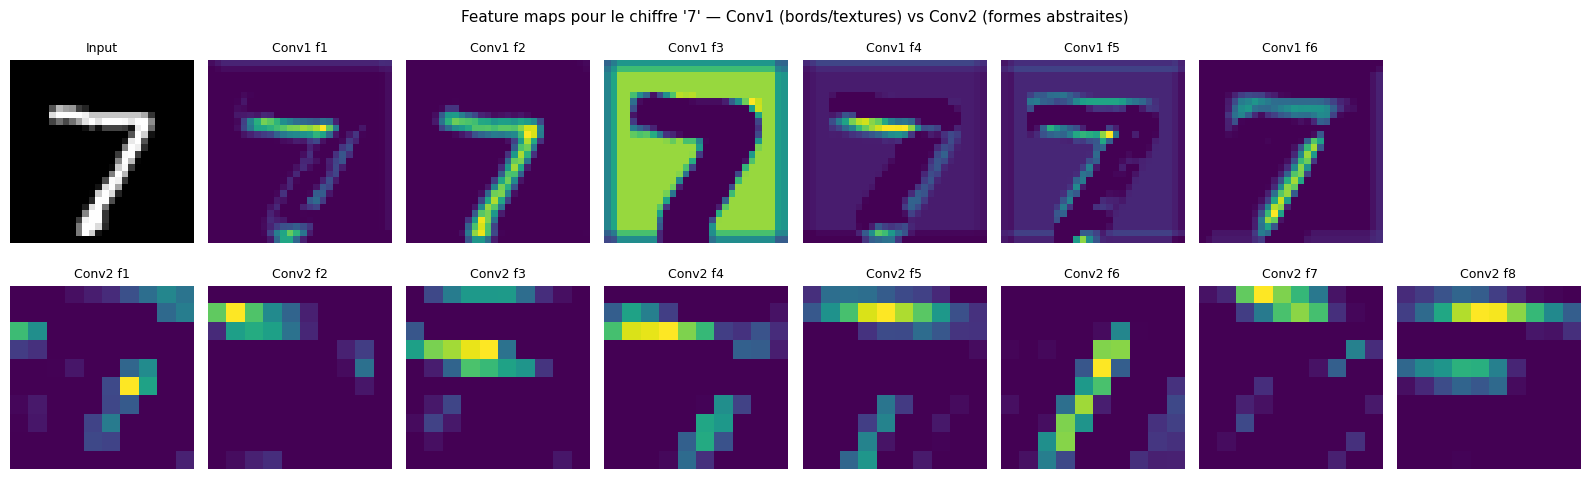

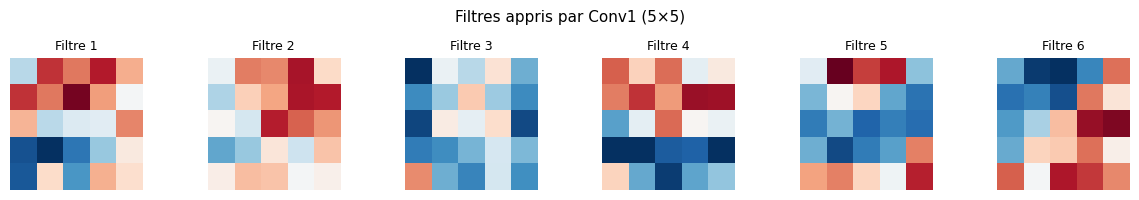

In [ ]:
# ============================================================
# VISUALISATION DES FEATURE MAPS
# ============================================================
# Les feature maps montrent CE QUE le CNN a appris à détecter.
# Couches basses : contours, textures simples
# Couches hautes : formes abstraites, parties d'objets
# ============================================================

model_lenet.load_state_dict(torch.load("best_lenet.pt",
                            map_location='cpu'))
model_lenet.eval()

# Prendre une image de test
img, label = test_data[0]
print(f"Chiffre sélectionné : {label}")

# --- Feature maps après Conv1 ---
with torch.no_grad():
    x = img.unsqueeze(0)                          # [1,1,28,28]
    feat1 = F.relu(model_lenet.conv1(x))          # [1,6,28,28]
    feat2_in = model_lenet.pool1(feat1)            # [1,6,14,14]
    feat2 = F.relu(model_lenet.conv2(feat2_in))   # [1,16,10,10]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))

# Ligne 1 : image originale + 6 filtres Conv1 + 1 vide
axes[0, 0].imshow(img.squeeze(), cmap='gray')
axes[0, 0].set_title("Input", fontsize=9)
axes[0, 0].axis('off')

for i in range(6):
    axes[0, i+1].imshow(feat1[0, i].numpy(), cmap='viridis')
    axes[0, i+1].set_title(f"Conv1 f{i+1}", fontsize=9)
    axes[0, i+1].axis('off')
axes[0, 7].axis('off')

# Ligne 2 : 8 des 16 filtres Conv2
for i in range(8):
    axes[1, i].imshow(feat2[0, i].numpy(), cmap='viridis')
    axes[1, i].set_title(f"Conv2 f{i+1}", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle(f"Feature maps pour le chiffre '{label}' — "
             f"Conv1 (bords/textures) vs Conv2 (formes abstraites)",
             fontsize=11)
plt.tight_layout()
plt.show()

# --- Visualisation des filtres appris ---
filters = model_lenet.conv1.weight.detach().numpy()  # [6,1,5,5]
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(filters[i, 0], cmap='RdBu_r',
                   vmin=-filters.max(), vmax=filters.max())
    axes[i].set_title(f"Filtre {i+1}", fontsize=9)
    axes[i].axis('off')
plt.suptitle("Filtres appris par Conv1 (5×5)", fontsize=11)
plt.tight_layout()
plt.show()

Paramètres MLP : 235,146
Paramètres CNN : 61,706

--- Entraînement MLP ---
Epoch  1/10 | Loss: 0.3139 | Acc: 0.9560
Epoch  2/10 | Loss: 0.1540 | Acc: 0.9704
Epoch  3/10 | Loss: 0.1265 | Acc: 0.9728
Epoch  4/10 | Loss: 0.1092 | Acc: 0.9735
Epoch  5/10 | Loss: 0.0948 | Acc: 0.9777
Epoch  6/10 | Loss: 0.0889 | Acc: 0.9742
Epoch  7/10 | Loss: 0.0821 | Acc: 0.9803
Epoch  8/10 | Loss: 0.0763 | Acc: 0.9770
Epoch  9/10 | Loss: 0.0726 | Acc: 0.9798
Epoch 10/10 | Loss: 0.0703 | Acc: 0.9812

Meilleure accuracy : 0.9812

--- Entraînement CNN (LeNet) ---
Epoch  1/10 | Loss: 0.2797 | Acc: 0.9694
Epoch  2/10 | Loss: 0.0830 | Acc: 0.9821
Epoch  3/10 | Loss: 0.0609 | Acc: 0.9813
Epoch  4/10 | Loss: 0.0483 | Acc: 0.9868
Epoch  5/10 | Loss: 0.0378 | Acc: 0.9872
Epoch  6/10 | Loss: 0.0327 | Acc: 0.9871
Epoch  7/10 | Loss: 0.0278 | Acc: 0.9898
Epoch  8/10 | Loss: 0.0250 | Acc: 0.9864
Epoch  9/10 | Loss: 0.0207 | Acc: 0.9909
Epoch 10/10 | Loss: 0.0185 | Acc: 0.9882

Meilleure accuracy : 0.9909


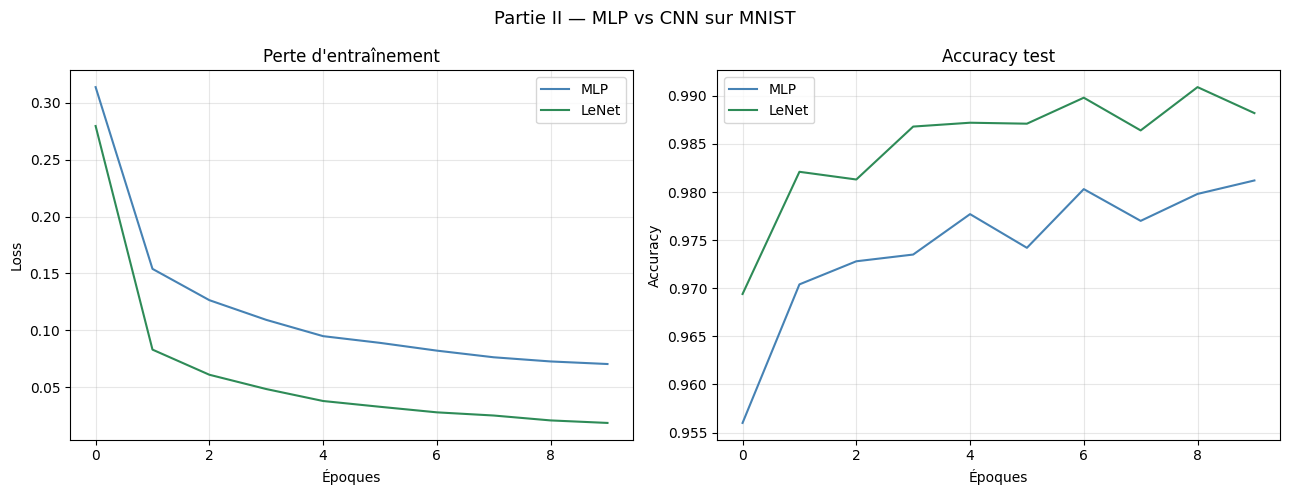


=== Résultats finaux ===
MLP  — Accuracy : 0.9812 | Params : 235,146
LeNet — Accuracy : 0.9909 | Params : 61,706


In [ ]:
# ============================================================
# COMPARAISON MLP vs CNN SUR MNIST
# ============================================================

class MLP_MNIST(nn.Module):
    """MLP simple pour MNIST — même nombre de paramètres ~approx."""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.flatten(start_dim=1)   # [B,1,28,28] → [B,784]
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

mlp_mnist = MLP_MNIST()
cnn_mnist  = LeNet()

params_mlp = sum(p.numel() for p in mlp_mnist.parameters())
params_cnn = sum(p.numel() for p in cnn_mnist.parameters())
print(f"Paramètres MLP : {params_mlp:,}")
print(f"Paramètres CNN : {params_cnn:,}")

print("\n--- Entraînement MLP ---")
hist_mlp = train_cnn(mlp_mnist, train_loader, test_loader,
                     epochs=10, model_name="mlp_mnist")

print("\n--- Entraînement CNN (LeNet) ---")
hist_cnn = train_cnn(cnn_mnist, train_loader, test_loader,
                     epochs=10, model_name="cnn_mnist")

# --- Courbes comparatives ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(hist_mlp["train_loss"], label="MLP",  color="steelblue")
axes[0].plot(hist_cnn["train_loss"], label="LeNet", color="seagreen")
axes[0].set_title("Perte d'entraînement")
axes[0].set_xlabel("Époques"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_mlp["test_acc"], label="MLP",  color="steelblue")
axes[1].plot(hist_cnn["test_acc"], label="LeNet", color="seagreen")
axes[1].set_title("Accuracy test")
axes[1].set_xlabel("Époques"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Partie II — MLP vs CNN sur MNIST", fontsize=13)
plt.tight_layout(); plt.show()

# --- Tableau final ---
print("\n=== Résultats finaux ===")
print(f"MLP  — Accuracy : {max(hist_mlp['test_acc']):.4f} | Params : {params_mlp:,}")
print(f"LeNet — Accuracy : {max(hist_cnn['test_acc']):.4f} | Params : {params_cnn:,}")